    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca thal  target  
0    3.0  0.0  6.0       0  
1    2.0  3.0  3.0       2  
2    2.0  2.0  7.0       1  
3    3.0  0.0  3.0       0  
4    1.0  0.0  3.0       0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-n

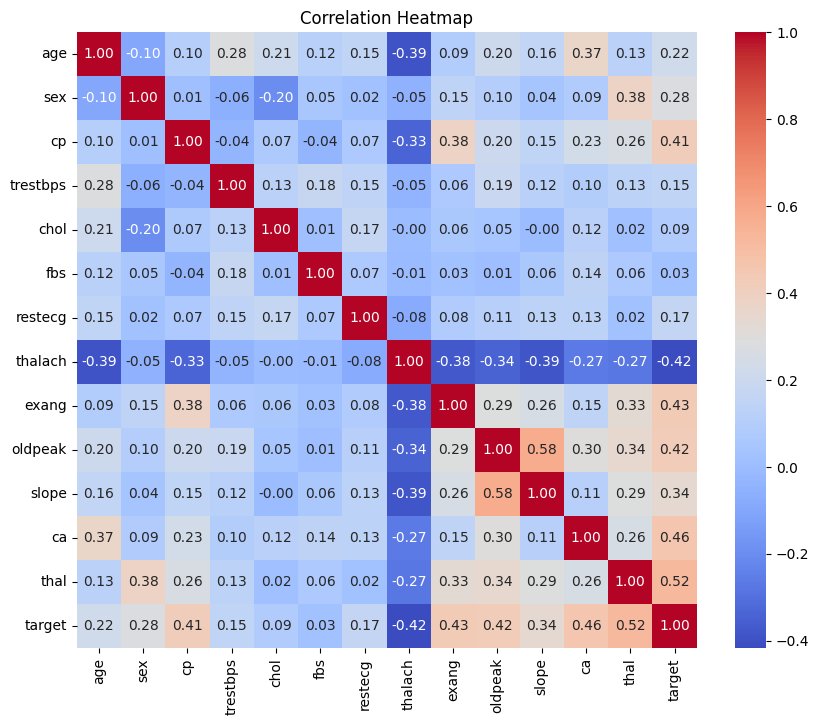

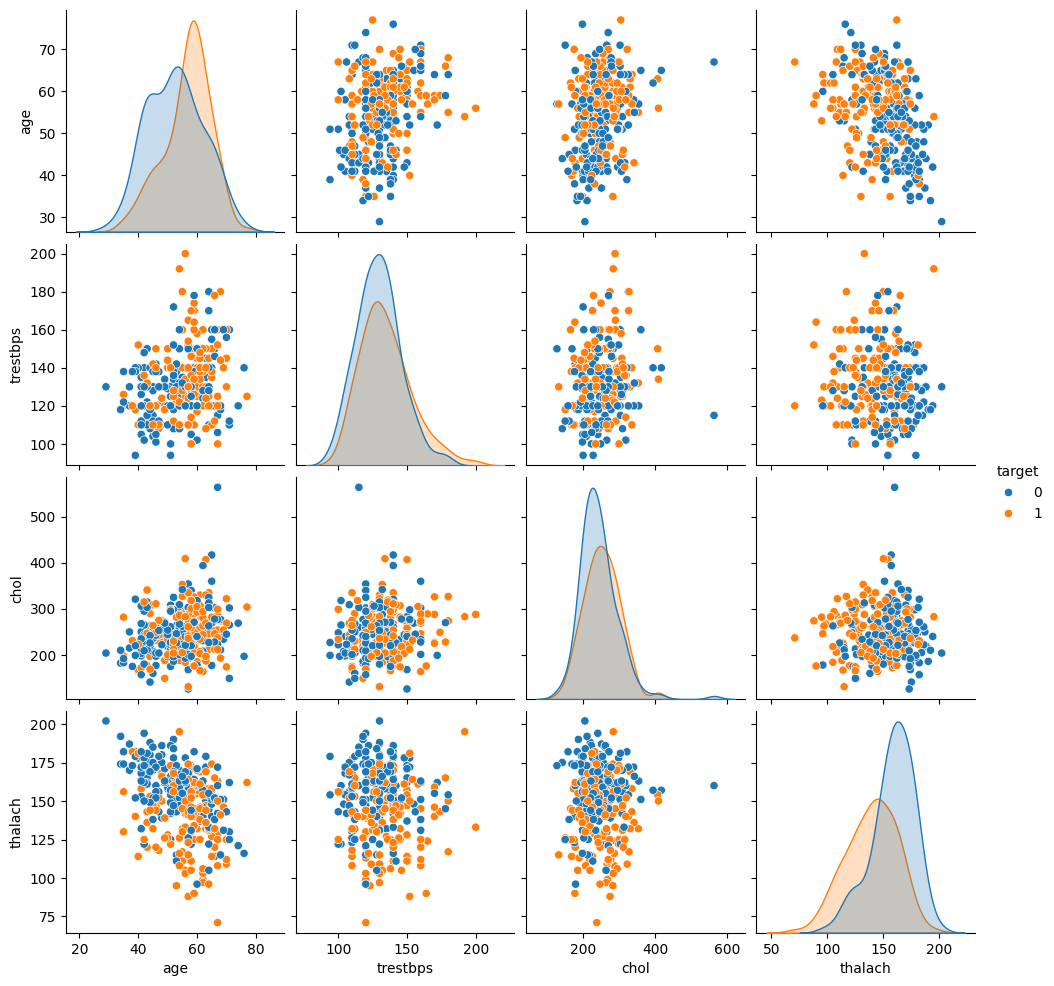

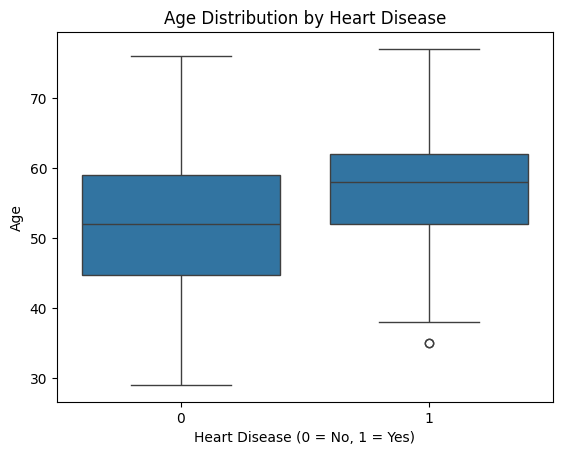

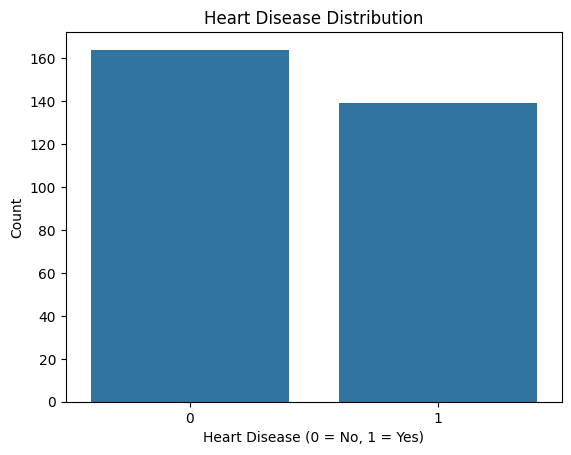

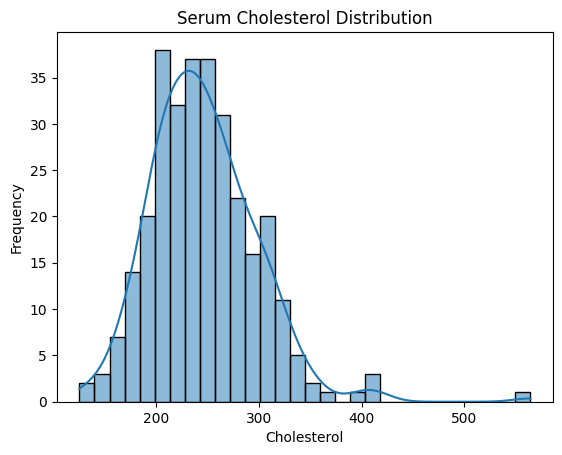

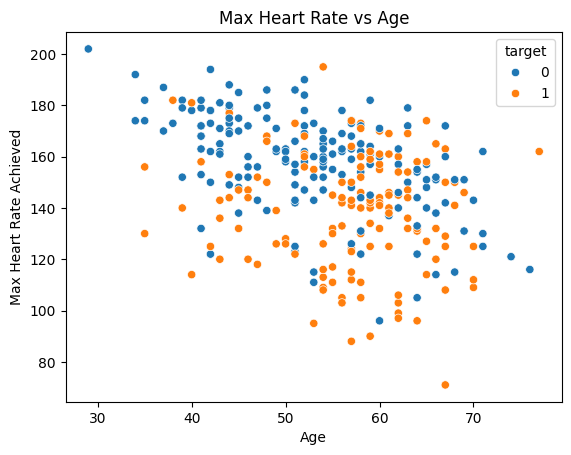

In [2]:
# 1. Import Libraries
columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
df = pd.read_csv(url, header=None, names=columns)


# 3. Inspect Data
print(df.head())
print(df.info())
print(df.describe())


# 4. Data Cleaning
df.replace('?', pd.NA, inplace=True) # Replace '?' with NaN
df = df.apply(pd.to_numeric, errors='coerce') # Convert all columns to numeric
df.fillna(df.median(), inplace=True) # Fill missing values with median


# Convert categorical variables
df['sex'] = df['sex'].map({0: 'female', 1: 'male'})
df['target'] = df['target'].apply(lambda x: 0 if x==0 else 1) # 0 = No, 1 = Yes


# 5. Prepare numeric dataset for correlation
numeric_df = df.copy()
numeric_df['sex'] = numeric_df['sex'].map({'female': 0, 'male': 1})


# 6. EDA Visualizations


# a) Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


# b) Pairplot for selected features
sns.pairplot(numeric_df[['age', 'trestbps', 'chol', 'thalach', 'target']], hue='target')
plt.show()


# c) Boxplot - Age by Target
sns.boxplot(x='target', y='age', data=df)
plt.title('Age Distribution by Heart Disease')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Age')
plt.show()


# d) Count Plot - Target Distribution
sns.countplot(x='target', data=df)
plt.title('Heart Disease Distribution')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()


# e) Histogram - Cholesterol Distribution
sns.histplot(df['chol'], bins=30, kde=True)
plt.title('Serum Cholesterol Distribution')
plt.xlabel('Cholesterol')
plt.ylabel('Frequency')
plt.show()


# f) Scatter plot - Max Heart Rate vs Age colored by Target
sns.scatterplot(x='age', y='thalach', hue='target', data=df)
plt.title('Max Heart Rate vs Age')
plt.xlabel('Age')
plt.ylabel('Max Heart Rate Achieved')
plt.show()